In [35]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [36]:
df = pd.read_csv('/content/Klasifikasi Tingkat Kemiskinan di Indonesia.csv')
df.head()

,Provinsi,Kab/Kota,Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen),Rata-rata Lama Sekolah Penduduk 15+ (Tahun),Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun),Indeks Pembangunan Manusia,Umur Harapan Hidup (Tahun),Persentase rumah tangga yang memiliki akses terhadap sanitasi layak,Persentase rumah tangga yang memiliki akses terhadap air minum layak,Tingkat Pengangguran Terbuka,Tingkat Partisipasi Angkatan Kerja,PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah),Klasifikasi Kemiskinan
0,ACEH,Simeulue,18.98,9.48,7148,66.41,65.28,71.56,87.45,5.71,71.15,1648096,0
1,ACEH,Aceh Singkil,20.36,8.68,8776,69.22,67.43,69.56,78.58,8.36,62.85,1780419,1
2,ACEH,Aceh Selatan,13.18,8.88,8180,67.44,64.40,62.55,79.65,6.46,60.85,4345784,0
3,ACEH,Aceh Tenggara,13.41,9.67,8030,69.44,68.22,62.71,86.71,6.43,69.62,3487157,0
4,ACEH,Aceh Timur,14.45,8.21,8577,67.83,68.74,66.75,83.16,7.13,59.48,8433526,0


Membaca dataset Klasifikasi Tingkat Kemiskinan di Indonesia
df.head() menampilkan 5 data pertama untuk melihat struktur data
Dataset ini berisi data indikator sosial, pendidikan, kesehatan, dan ekonomi daerah yang digunakan untuk menentukan klasifikasi tingkat kemiskinan.

In [37]:
# menentukan variabel
X = df[[
    'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
    'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)',
    'Indeks Pembangunan Manusia',
    'Umur Harapan Hidup (Tahun)',
    'Persentase rumah tangga yang memiliki akses terhadap sanitasi layak',
    'Persentase rumah tangga yang memiliki akses terhadap air minum layak',
    'Tingkat Pengangguran Terbuka',
    'Tingkat Partisipasi Angkatan Kerja',
    'PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)'
]]

y = df['Klasifikasi Kemiskinan']

In [38]:
# normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
# model KNN
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [41]:
# prediksi
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.883495145631068


In [42]:
# pengujian variasi K pada KNN
for k in [3,5,7]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"K={k}, Accuracy={accuracy_score(y_test, y_pred)}")

K=3, Accuracy=0.883495145631068
K=5, Accuracy=0.8737864077669902
K=7, Accuracy=0.8737864077669902


In [43]:
# buat grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

In [44]:
# ambil rata-rata tiap kolom
mean_vals = df.mean(numeric_only=True)

# buat grid dari 2 fitur utama (misalnya ambil 2 pertama)
grid = np.c_[xx.ravel(), yy.ravel()]

# tambahkan 7 fitur sisanya (HARUS sesuai urutan X)
grid_full = np.c_[
    grid,
    np.full(xx.ravel().shape, mean_vals['Indeks Pembangunan Manusia']),
    np.full(xx.ravel().shape, mean_vals['Umur Harapan Hidup (Tahun)']),
    np.full(xx.ravel().shape, mean_vals['Persentase rumah tangga yang memiliki akses terhadap sanitasi layak']),
    np.full(xx.ravel().shape, mean_vals['Persentase rumah tangga yang memiliki akses terhadap air minum layak']),
    np.full(xx.ravel().shape, mean_vals['Tingkat Pengangguran Terbuka']),
    np.full(xx.ravel().shape, mean_vals['Tingkat Partisipasi Angkatan Kerja']),
    np.full(xx.ravel().shape, mean_vals['PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)'])
]

# prediksi
Z = model.predict(grid_full)
Z = Z.reshape(xx.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


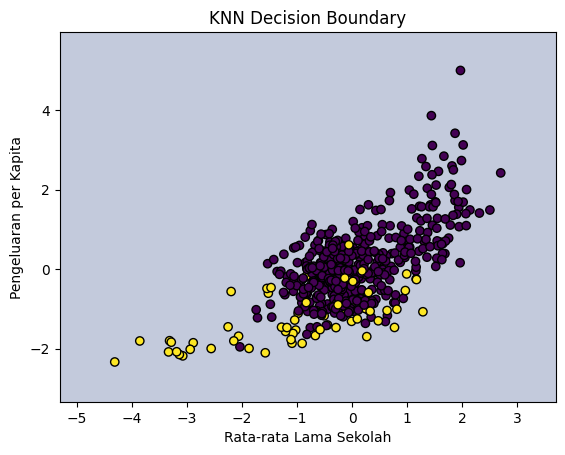

In [45]:
# plot grafik
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolor='k')

plt.xlabel("Rata-rata Lama Sekolah")
plt.ylabel("Pengeluaran per Kapita")
plt.title("KNN Decision Boundary")
plt.show()

Grafik menunjukkan pola bahwa semakin tinggi rata-rata lama sekolah, semakin tinggi pula pengeluaran per kapita, yang terlihat dari sebaran titik yang naik dari kiri bawah ke kanan atas. Namun, titik dari kedua kelas masih banyak yang bercampur, terutama di area tengah, sehingga tidak ada pemisahan yang jelas antar kelas. Warna latar (decision boundary) juga terlihat hampir seragam tanpa batas yang tegas, menandakan model KNN belum mampu membedakan kelas dengan baik jika hanya dilihat dari dua variabel ini. Hal ini menunjukkan bahwa kedua variabel tersebut belum cukup kuat untuk memisahkan tingkat kemiskinan secara akurat, sehingga diperlukan fitur lain agar hasil klasifikasi lebih jelas.